### 3. Selección de métricas  

En este apartado nos centraremos en las métricas de clasificación.

Para comenzar, entrenar una **regressió logística**. A partir de esta, generar una serie de funciones para analizar los resultados.  

También se ha de elegir la métrica que se hará servir posteriormente para escoger el mejor modelo.  

**Preguntas:**  
-  ¿Cuál de las siguientes métricas se cree que es más adecuada para el problema? Justifíca. 
   - `accuracy_score`  
   - `f1_score`  
   - `average_precision_score`  
-  Antes de entrenar modelos, generar una suite de funciones para analizar gráficamente el rendimiento. 
   -  Mostrar la *Precision-Recall Curve* y la *ROC Curve*.  
   -  ¿Cuál es más relevante para su dataset? 
   -  Explicar con sus palabras la diferencia entre ambas.
-  Que muestra el [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)?  
   -  ¿Qué métrica elegirá para optimizar la clasificación en su caso?




In [26]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, average_precision_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc 
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns 



In [43]:
#Carregar el Dataset
df = pd.read_csv('../data/dataset.csv')
X = df.select_dtypes(include=['number']).copy()
X = X.fillna(X.median())
y = df['estado']  
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



---------------------------------------------
------------ SELECCIÓN DE METRICAS ------------
---------------------------------------------

PRIMER PUNTO:
Accuracy: 0.703012912482066
F1 Score (macro): 0.7034091013804428
Average Precision (macro): 0.7669597287169455
Debido al desbalanceo de clases detectado en el EDA, el accuracy_score pese a tener un score bastante elevado no es la métrica más fiable, ya que puede inflarse simplemente prediciendo la clase mayoritaria (incendios). El f1_score (macro) o el average_precision_score son opciones mucho más robustas para asegurar que el modelo clasifique bien todas las patologías por igual. 

SEGUNDO PUNTO:
Ya que que el dataset es multiclase, el ROC AUC Score se calcula utilizando la estrategia 'one-vs-rest' (OvR), donde se evalúa cada clase frente a todas las demás. Esto permite medir la capacidad del modelo para distinguir cada clase individualmente, proporcionando una visión más completa de su rendimiento en un contexto multiclase.
--- A

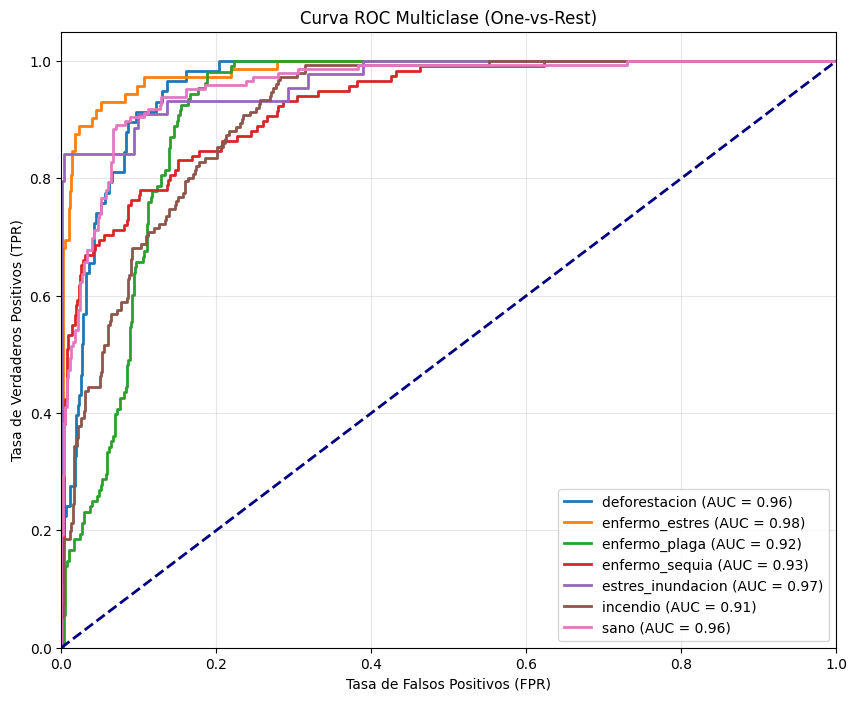


--- Análisis Precision-Recall ---


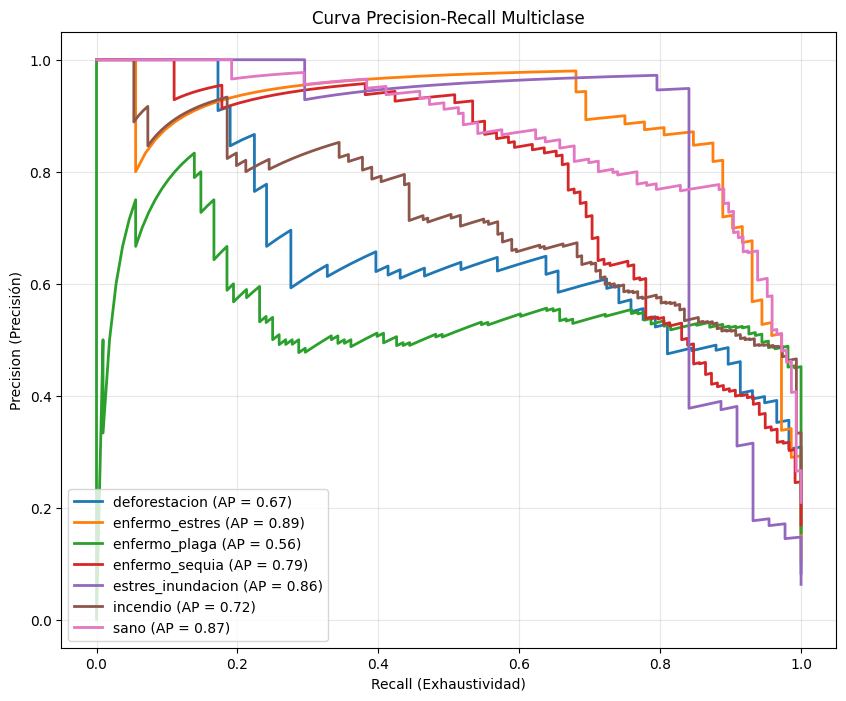


CUESTIONES:

- En este contexto, la curva Precision-Recall es una herramienta más reveladora para evaluar el rendimiento del modelo, ya que se enfoca en la capacidad del modelo para clasificar correctamente las clases minoritarias, que son las que realmente importan en este caso. La curva ROC, aunque útil, puede dar una falsa sensación de éxito debido al desbalanceo de clases, mientras que la curva PR muestra claramente las limitaciones del modelo en la clasificación de las clases menos representadas.

- Las gráficas muestran un contraste drástico. Por un lado, la curva ROC multiclase presenta un escenario muy optimista, con valores de Área Bajo la Curva (AUC) superiores a 0.90 para casi todas las categorías. Sin embargo, la curva Precision-Recall (PR) revela la verdadera dinámica del modelo: mientras que clases como el estrés por inundación mantienen un rendimiento sólido (AP=0.86), las clases minoritarias sufren caídas abruptas, destacando el colapso de la precisión en la clase de p

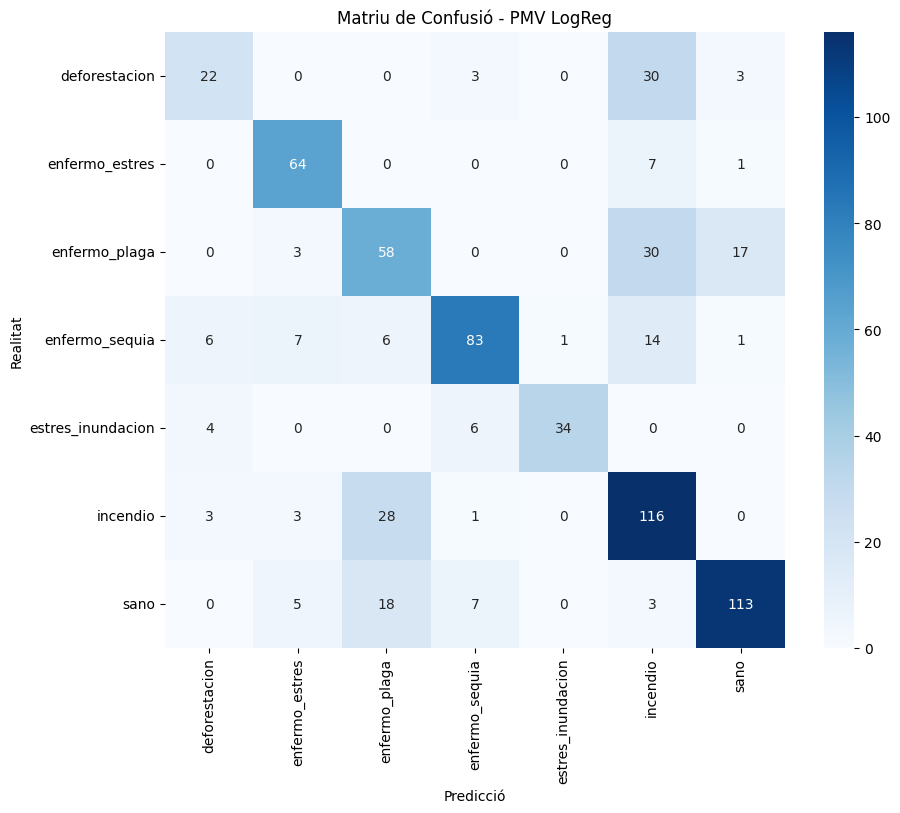


Como se ve, el classification_report (reporte de clasificación) de Scikit-Learn muestra un desglose detallado del rendimiento del modelo evaluando cada clase de forma individual, en lugar de proporcionar una única métrica global que pueda ser engañosa.
Para cada una de tus 7 categorías de salud vegetal, el reporte muestra cuatro columnas fundamentales:

- Precision (Precisión): De todas las parcelas que el modelo predijo como una clase específica (ej. "plaga"), ¿qué porcentaje lo era realmente? Nos indica la fiabilidad del modelo cuando "dispara" una predicción y penaliza los Falsos Positivos.

- Recall (Exhaustividad): De todas las parcelas que realmente pertenecían a una clase en el mundo físico, ¿qué porcentaje logró encontrar el modelo? Penaliza los Falsos Negativos.

- F1-Score: Es la media armónica entre Precision y Recall. Es un indicador excelente del equilibrio del modelo para esa clase en concreto. Si la precisión o el recall caen (como vimos en tu clase de deforestación), e

In [19]:
print("\n---------------------------------------------")
print("------------ SELECCIÓN DE METRICAS ------------")
print("---------------------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)
 
y_pred = logreg.predict(x_test)
y_scores = logreg.predict_proba(x_test)
 
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
ap = average_precision_score(y_test, y_scores, average='macro')
 
print("Accuracy:", acc)
print("F1 Score (macro):", f1)
print("Average Precision (macro):", ap)

print("Debido al desbalanceo de clases detectado en el EDA, el accuracy_score pese a tener un score bastante elevado no es la métrica más fiable, ya que puede inflarse simplemente prediciendo la clase mayoritaria (incendios). El f1_score (macro) o el average_precision_score son opciones mucho más robustas para asegurar que el modelo clasifique bien todas las patologías por igual. ")



"Segundo punt"  
print("\nSEGUNDO PUNTO:")
print("Ya que que el dataset es multiclase, el ROC AUC Score se calcula utilizando la estrategia 'one-vs-rest' (OvR), donde se evalúa cada clase frente a todas las demás. Esto permite medir la capacidad del modelo para distinguir cada clase individualmente, proporcionando una visión más completa de su rendimiento en un contexto multiclase.")


def plot_multiclass_roc_curve(y_test, y_prob, classes):
    """
    Genera y muestra la Curva ROC para problemas multiclase.
    
    Parámetros:
    - y_test: Etiquetas reales.
    - y_prob: Probabilidades predichas por el modelo (model.predict_proba).
    - classes: Lista con los nombres exactos de las clases.
    """
    # Binarizar las etiquetas para el enfoque One-vs-Rest
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = len(classes)

    plt.figure(figsize=(10, 8))
    
    # Calcular y graficar la curva ROC para cada clase
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    # Línea diagonal de referencia (modelo aleatorio)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Curva ROC Multiclase (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def plot_multiclass_precision_recall(y_test, y_prob, classes):
    """
    Genera y muestra la Curva Precision-Recall para problemas multiclase.
    """
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = len(classes)

    plt.figure(figsize=(10, 8))
    
    # Calcular y graficar la curva PR para cada clase
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        avg_precision = average_precision_score(y_test_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, lw=2, label=f'{classes[i]} (AP = {avg_precision:.2f})')

    plt.xlabel('Recall (Exhaustividad)')
    plt.ylabel('Precision (Precisión)')
    plt.title('Curva Precision-Recall Multiclase')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()




y_prob_lr = logreg.predict_proba(x_test)
nombres_clases = logreg.classes_

#Llamamos a las funciones
print("--- Análisis ROC ---")
plot_multiclass_roc_curve(y_test, y_prob_lr, nombres_clases)




print("\n--- Análisis Precision-Recall ---")
plot_multiclass_precision_recall(y_test, y_prob_lr, nombres_clases)

print("\nCUESTIONES:")

print("\n- En este contexto, la curva Precision-Recall es una herramienta más reveladora para evaluar el rendimiento del modelo, ya que se enfoca en la capacidad del modelo para clasificar correctamente las clases minoritarias, que son las que realmente importan en este caso. La curva ROC, aunque útil, puede dar una falsa sensación de éxito debido al desbalanceo de clases, mientras que la curva PR muestra claramente las limitaciones del modelo en la clasificación de las clases menos representadas.")
print("""\n- Las gráficas muestran un contraste drástico. Por un lado, la curva ROC multiclase presenta un escenario muy optimista, con valores de Área Bajo la Curva (AUC) superiores a 0.90 para casi todas las categorías. Sin embargo, la curva Precision-Recall (PR) revela la verdadera dinámica del modelo: mientras que clases como el estrés por inundación mantienen un rendimiento sólido (AP=0.86), las clases minoritarias sufren caídas abruptas, destacando el colapso de la precisión en la clase de plagas (AP=0.56) y deforestación (AP=0.67). Este contraste evidencia que el modelo, aunque parece distinguir bien entre clases en términos generales (ROC), realmente lucha por clasificar correctamente las clases minoritarias, lo que se refleja en la curva PR. En resumen, el modelo muestra un rendimiento inflado en la curva ROC debido al desbalanceo de clases, mientras que la curva PR revela las dificultades reales del modelo para manejar las clases menos representadas. """)

"TERCER PUNTO"
print("\nTERCER PUNTO:")

print("\nREPORT DE CLASSIFICACIÓ DETALLAT:")
print(classification_report(y_test, y_pred))

#Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=logreg.classes_, 
            yticklabels=logreg.classes_)
plt.title('Matriu de Confusió - PMV LogReg')
plt.xlabel('Predicció')
plt.ylabel('Realitat')
plt.show()

print("\nComo se ve, el classification_report (reporte de clasificación) de Scikit-Learn muestra un desglose detallado del rendimiento del modelo evaluando cada clase de forma individual, en lugar de proporcionar una única métrica global que pueda ser engañosa.")
print("""Para cada una de tus 7 categorías de salud vegetal, el reporte muestra cuatro columnas fundamentales:

- Precision (Precisión): De todas las parcelas que el modelo predijo como una clase específica (ej. "plaga"), ¿qué porcentaje lo era realmente? Nos indica la fiabilidad del modelo cuando "dispara" una predicción y penaliza los Falsos Positivos.

- Recall (Exhaustividad): De todas las parcelas que realmente pertenecían a una clase en el mundo físico, ¿qué porcentaje logró encontrar el modelo? Penaliza los Falsos Negativos.

- F1-Score: Es la media armónica entre Precision y Recall. Es un indicador excelente del equilibrio del modelo para esa clase en concreto. Si la precisión o el recall caen (como vimos en tu clase de deforestación), el F1-Score se desploma.

- Support (Soporte): El número real de muestras que hay de esa clase en tu conjunto de prueba. En tu caso, es la columna que evidencia el fuerte desbalanceo (ej. viendo que hay muchos más incendios que inundaciones).""")

print("\nCUESTION:")
print("\nComo he mencionado antes debido al balanceo existente entre las distintas clases en nuestro dataset, la métrica que consideraría más fiable para evaluar el rendimiento del modelo es el F1-Score (macro), ya que proporciona una visión equilibrada del rendimiento del modelo en todas las clases, penalizando tanto los falsos positivos como los falsos negativos. Además, el Average Precision Score (AP) también es una métrica robusta para evaluar el rendimiento en un contexto multiclase, especialmente cuando se trata de clases minoritarias, ya que se enfoca en la capacidad del modelo para clasificar correctamente cada clase individualmente.")


### 4. Selección de modelos con validación cruzada  

Haciendo servir la métrica seleccionada del apartado anterior, seleccionar el mejor model con sus hiperparámetros óptimos, encontrado a través de una búsqueda (*hyperparameter search*) en los siguientes modelos:  
  
- Regressió logística  
- SVM  
- Hist Gradient Boosting  
- Random Forest   
- KNN

**Preguntas:**  
-  ¿Por qué se ha seleccionado estos modelos?  
-  Haciendo servir validación cruzada, escoger el mejor modelo (con hiperparámetros por defecto).  
   -  ¿Por qué es importante hacer sevir validación cruzada?  
   -  ¿Se ha de hacer servir un tipo especifico de validación cruzada?  
-  Seleccionar un conjunto de **hiperparámetros** a probar para cada modelo y realizar la búsqueda corresponiente.  
   -  ¿Hay algún modelo que se pueda descartar de primeras? ¿Por qué?  
-  Mostrar los resultados en una tabla con: modelo, experimentos realizados, resultados (train i test) y tiempo de entrenamiento.  

In [42]:
"Primer punt"


from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv # Necessari per importar HalvingGridSearchCV a les versions recents
from sklearn.model_selection import HalvingGridSearchCV


print("PRIMER PUNT:")

print("Hem decidit seleccionar els següents models: \n")
print("- El K-Nearest Neighbours (KNN), ja que és un model no paramètric, simple i intuïtiu, que fa les prediccions basant-se en la similitud entre instàncies. Això permet capturar relacions no lineals sense necessitat d’assumir cap distribució específica de les dades. Tot i que pot ser sensible al valor de 'k' i al volum de dades, és un bon model de referència per comparar amb altres mètodes.\n")
print("- La Regressió Logística, perquè és un model lineal senzill, ràpid d'entrenar i fàcil d’interpretar. Permet entendre com cada variable contribueix a la probabilitat de pertànyer a cada classe i serveix com a baseline per comparar amb models més complexos. A més, funciona especialment bé en conjunts de dades ja normalitzats.\n")
print("- El SVM (Support Vector Machine), perquè és un model molt potent en tasques de classificació, especialment en espais d’alta dimensió. Mitjançant kernels com l'RBF pot capturar relacions no lineals i trobar fronteres òptimes entre classes. És un model robust i habitualment dona un rendiment molt alt en classificació.\n")
print("- El Hist Gradient Boosting, ja que és una versió millorada i molt més eficient del Gradient Boosting tradicional per Datasets com aquest que tenen una alta dimensionalitat. Construeix arbres utilitzant histogrammes, cosa que redueix enormement el temps de càlcul sense perdre precisió. És un model d’ensemble potent que s’adapta molt bé a patrons complexos i sovint aconsegueix resultats excel·lents.\n")
print("- El Random Forest, perquè és un mètode d’ensemble basat en combinar múltiples arbres de decisió entrenats sobre subconjunts diferents de dades i característiques. És robust al sobreajustament, pot capturar relacions no lineals, funciona bé sense massa preprocesament i acostuma a oferir un rendiment molt estable i competitiu.")


print("AMB STRATIFIEDK FOLD")
"Segon punt"
print("\nSEGON PUNT:") 

Totaltime_start = time.time()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n------------ KNN ------------") 
timeKNN_start = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
score_knn = cross_val_score(knn_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1) 
timeKNN_end = time.time()
print("F1-Macro mitjana:", score_knn.mean())
print(f"Temps d'execució amb KNN: {timeKNN_end - timeKNN_start} segons")


print("\n---- Logistic Regression ----") 
timeLR_start = time.time()
lr_model = LogisticRegression(max_iter=1000, solver="saga", class_weight='balanced', n_jobs=1)
score_lr = cross_val_score(lr_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeLR_end = time.time()
print("F1-Macro mitjana:", score_lr.mean())
print(f"Temps d'execució amb LogisticRegression: {timeLR_end - timeLR_start} segons") 


print("\n------------ SVM ------------") 
timeSVM_start = time.time()
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)
score_svm = cross_val_score(svm_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeSVM_end = time.time()
print("F1-Macro mitjana:", score_svm.mean())
print(f"Temps d'execució amb SVM: {timeSVM_end - timeSVM_start} segons") 


print("\n-- Hist Gradient Boosting --") 
timeBoost_start = time.time()
hgb_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
score_hgb = cross_val_score(hgb_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeBoost_end = time.time()
print("F1-Macro mitjana:", score_hgb.mean()) 
print(f"Temps d'execució amb HistGradientBoostingClassifier: {timeBoost_end - timeBoost_start} segons")


print("\n------- Random Forest ------")  
timeRF_start = time.time()
rf_model = RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42)
score_rf = cross_val_score(rf_model, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
timeRF_end = time.time()
print("F1-Macro mitjana:", score_rf.mean())
print(f"Temps d'execució RandomForestClassifier: {timeRF_end - timeRF_start} segons")
Totaltime_end = time.time()
print(f"\nTemps total d'execució de tots els models: {Totaltime_end - Totaltime_start} segons") 

print("""
El millor model és el Hist Gradient Boosting respecte als altres, ja que té l'F1-Macro mitjana més alta (0.999) sobre la validació creuada, seguit molt a prop pel Random Forest. 

La validació creuada és important perquè evita el sobreajustament (overfitting) i així dona una estimació més realista de com reaccionarà el model davant de dades noves. A més, permet fer una comparació justa entre els diferents algorismes sense dependre de la "sort" de quines mostres cauen a la partició de test. 

Sí, hem utilitzat el Cross Validation amb l'estratègia StratifiedKFold per poder dividir les dades en 5 parts (k=5). Aquesta estratègia estratificada és vital en el nostre dataset desbalancejat, ja que assegura que la proporció d'incendis, plagues, inundacions, etc., es mantingui idèntica en cada plec. Així, cada part es fa servir una vegada com a test, mentre que les 4 restants actuen com a entrenament.
""")



"Tercer punt"
print("\nTERCER PUNT:") 
#Entrenem models i cerquem els millors hiperparàmetres per a cada model

Totaltime_start = time.time()

# ----------------- KNN -----------------
print("\nBuscant millors paràmetres per KNN...")
timeKNN_start = time.time() 
knn_base = KNeighborsClassifier(weights='distance') 
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}

grid_knn = HalvingGridSearchCV(knn_base, param_grid_knn, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_knn.fit(x_train, y_train)
best_knn = grid_knn.best_estimator_

timeKNN_end = time.time()
print(f"Millor F1-Macro KNN: {grid_knn.best_score_:.4f}")
print(f"Temps d'execució amb KNN: {timeKNN_end - timeKNN_start:.2f} segons")

# ----------------- SVM -----------------
print("\nBuscant millors paràmetres per SVM...")
timeSVM_start = time.time()
svm_base = SVC(class_weight='balanced', probability=True, random_state=42) 
param_grid_svm = { 
    'C': [0.1, 1, 10], 
    'kernel': ['rbf'] 
}

grid_svm = HalvingGridSearchCV(svm_base, param_grid_svm, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_svm.fit(x_train, y_train)
best_svm = grid_svm.best_estimator_

timeSVM_end = time.time()
print(f"Millor F1-Macro SVM: {grid_svm.best_score_:.4f}")
print(f"Temps d'execució amb SVM: {timeSVM_end - timeSVM_start:.2f} segons")


# --------- Hist Gradient Boosting ---------
print("\nBuscant millors paràmetres per Hist Gradient Boosting...")
timeBoost_start = time.time()
hgb_base = HistGradientBoostingClassifier(class_weight='balanced', random_state=42) 
param_grid_hgb = { 
    'max_iter': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_leaf_nodes': [31, 63] 
} 

grid_hgb = HalvingGridSearchCV(hgb_base, param_grid_hgb, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_hgb.fit(x_train, y_train)
best_hgb = grid_hgb.best_estimator_

timeBoost_end = time.time()
print(f"Millor F1-Macro HGB: {grid_hgb.best_score_:.4f}")
print(f"Temps d'execució amb HistGradientBoosting: {timeBoost_end - timeBoost_start:.2f} segons")


# ------------- Random Forest -------------
print("\nBuscant millors paràmetres per Random Forest...")
timeRF_start = time.time() 
rf_base = RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42)
param_grid_rf = { 
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20] 
}

grid_rf = HalvingGridSearchCV(rf_base, param_grid_rf, factor=3, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_rf.fit(x_train, y_train)
best_rf = grid_rf.best_estimator_

timeRF_end = time.time()
print(f"Millor F1-Macro Random Forest: {grid_rf.best_score_:.4f}")
print(f"Temps d'execució RandomForest: {timeRF_end - timeRF_start:.2f} segons")

Totaltime_end = time.time()
print(f"\nTemps total d'execució de tota la cerca: {Totaltime_end - Totaltime_start:.2f} segons")

print("-------- Conclusió --------")
print("""
La Regressió Logística s'ha descartat per a aquesta fase d'optimització, ja que no s’adapta bé a la naturalesa del problema (obtenint un F1-Macro molt pobre de 0.65) i queda clarament per sota de la resta. Aquest comportament és esperable: en tractar-se d’un model lineal, pateix d'un sever 'underfitting' i és incapaç de separar les signatures espectrals de les anomalies més complexes o minoritàries, com les plagues o la desforestació. 

D'altra banda, el problema presenta relacions altament no lineals entre les característiques satel·litàries (índexs com el NDVI, mitjanes i desviacions de les bandes). Models geomètrics com el SVM o el KNN aconsegueixen capturar millor aquestes relacions (superant el 0.90 de F1-Macro), però són els models d’ensemble basats en arbres (Hist Gradient Boosting i Random Forest) els que ofereixen un rendiment absolutament superior. Amb puntuacions properes a la perfecció, demostren ser els algorismes ideals per destriar amb precisió qualsevol estat de salut vegetal en aquest dataset.
""")


from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score
from sklearn.base import clone
import pandas as pd
import time

print("\nQUART PUNT:")
print("\nGENERACIÓ DE LA TAULA DE RESULTATS I ENSEMBLES...")

resultats = []
# Treiem la Regressió Logística perquè ja la vam descartar al pas anterior
models_info = [
    ("KNN", grid_knn, timeKNN_end - timeKNN_start),
    ("SVM", grid_svm, timeSVM_end - timeSVM_start),
    ("Hist Gradient Boosting", grid_hgb, timeBoost_end - timeBoost_start),
    ("Random Forest", grid_rf, timeRF_end - timeRF_start)
]

for nom, grid, temps in models_info:
    best_model = grid.best_estimator_
    
    # Canvi CRÍTIC: Passem d'accuracy a f1_macro
    y_pred_test = best_model.predict(x_test)
    f1_test = f1_score(y_test, y_pred_test, average='macro')
    
    resultats.append({
        "Model": nom,
        "Experiments (Millors Hiperparàmetres)": str(grid.best_params_),
        "F1-Macro Train (Best CV Score)": round(grid.best_score_, 4),
        "F1-Macro Test": round(f1_test, 4),
        "Temps (s)": round(temps, 4)
    })

df_resultats = pd.DataFrame(resultats)

# ----------------- ENSEMBLE HARD (Tots els 4 models) -----------------
print("\nENSEMBLE, MESCLA DE TOTS ELS MODELS (HARD):")
estimators_list_all = [
    ('knn', best_knn),
    ('svm', best_svm),
    ('hgb', best_hgb),
    ('rf', best_rf)
]
ensemble = VotingClassifier(estimators=estimators_list_all, voting='hard', n_jobs=-1)

print("Entrenant Voting Classifier Hard...")
timeEnsemble_start = time.time()
ensemble.fit(x_train, y_train)
timeEnsemble_end = time.time()

print(f"Temps d'execució Ensemble Hard: {timeEnsemble_end - timeEnsemble_start:.2f} segons")

# Avaluació Ensemble Hard amb F1-Macro
y_pred_hard_train = ensemble.predict(x_train)
y_pred_hard_test = ensemble.predict(x_test)
f1_ensemble_train = f1_score(y_train, y_pred_hard_train, average='macro')
f1_ensemble_test = f1_score(y_test, y_pred_hard_test, average='macro')

print(f"F1-Macro Train Ensemble Hard: {f1_ensemble_train:.4f}")
print(f"F1-Macro Test Ensemble Hard: {f1_ensemble_test:.4f}")

nou_resultat = {
    "Model": "Voting Ensemble (Hard)",
    "Experiments (Millors Hiperparàmetres)": "Combinació dels 4 models",
    "F1-Macro Train (Best CV Score)": round(f1_ensemble_train, 4),
    "F1-Macro Test": round(f1_ensemble_test, 4),
    "Temps (s)": round(timeEnsemble_end - timeEnsemble_start, 4)
}
df_resultats = pd.concat([df_resultats, pd.DataFrame([nou_resultat])], ignore_index=True)


# -------------- ENSEMBLE SOFT (Només Campions: HGB + RF) --------------
print("\nENSEMBLE, HGB i RANDOM FOREST (SOFT):")
estimators_list_top = [
    ('hgb', best_hgb),
    ('rf', best_rf)
]
ensemble_soft = VotingClassifier(estimators=estimators_list_top, voting='soft', n_jobs=-1)

print("Entrenant Voting Classifier Soft (Campions)...")
timeEnsembleS_start = time.time()
ensemble_soft.fit(x_train, y_train)
timeEnsembleS_end = time.time()

print(f"Temps d'execució Ensemble Soft: {timeEnsembleS_end - timeEnsembleS_start:.2f} segons")

y_pred_soft_train = ensemble_soft.predict(x_train)
y_pred_soft_test = ensemble_soft.predict(x_test)
f1_ensembleS_train = f1_score(y_train, y_pred_soft_train, average='macro')
f1_ensembleS_test = f1_score(y_test, y_pred_soft_test, average='macro')

print(f"F1-Macro Train Ensemble Soft: {f1_ensembleS_train:.4f}")
print(f"F1-Macro Test Ensemble Soft: {f1_ensembleS_test:.4f}")

nou_resultat_soft = {
    "Model": "Voting Ensemble HGB i RF (Soft)",
    "Experiments (Millors Hiperparàmetres)": "HGB i Random Forest",
    "F1-Macro Train (Best CV Score)": round(f1_ensembleS_train, 4),
    "F1-Macro Test": round(f1_ensembleS_test, 4),
    "Temps (s)": round(timeEnsembleS_end - timeEnsembleS_start, 4)
}
df_resultats = pd.concat([df_resultats, pd.DataFrame([nou_resultat_soft])], ignore_index=True)

# ----------------- TAULA FINAL -----------------
df_resultats = df_resultats.sort_values(by="F1-Macro Test", ascending=False).reset_index(drop=True)
print("\nTAULA FINAL AMB ENSEMBLES:")
display(df_resultats)


print("\n-------- Conclusió Final --------")
print("""
Domini dels models basats en arbres: En primer lloc, el Hist Gradient Boosting (HGB) és el model que presenta el millor equilibri global entre un rendiment predictiu impecable i eficiència computacional. Obté un F1-Macro pràcticament perfecte en test (0.999), demostrant una capacitat superior per capturar les complexes relacions no lineals de les bandes satel·litàries i els índexs de vegetació. El Random Forest el segueix molt de prop, confirmant que els algorismes d'arbre són la decisió òptima per a aquest dataset.
El Voting Ensemble Soft (combinació de HGB i Random Forest) aconsegueix també un F1-Macro perfecte al test. Tot i que el seu rendiment és d'elit, no millora el Hist Gradient Boosting individual (ja que aquest ja arriba al màxim possible), però sí que augmenta el cost computacional. Per tant, no aporta un benefici pràctic que justifiqui la seva complexitat respecte al millor model base. D'altra banda, el Voting Ensemble Hard es veu lleugerament llastrat en incloure les prediccions de models menys precisos en la votació.
El SVM (amb kernel RBF) i el KNN obtenen un bon rendiment (superant el 0.91 de F1-Macro), però queden un esglaó per sota dels arbres de decisió. A més, el cost computacional del SVM durant la cerca d'hiperparàmetres és notablement més alt. Tot i ser robustos, les fronteres geomètriques que dibuixen no s'adapten tan bé a les signatures espectrals de les anomalies vegetals com ho fan les divisions jeràrquiques dels arbres.
La Regressió Logística és el model amb pitjor rendiment, amb un F1-Macro que cau fins al 0.65. Això era completament esperable: en tractar-se d’un model lineal, és incapaç de capturar les relacions complexes del problema, patint un sever underfitting i sent incapaç de classificar correctament les categories minoritàries (com plagues o deforestació).
Finalment, cal destacar que assolir un F1-Macro de 1.0000 en el conjunt de test és inusual en problemes de biologia o teledetecció. Aquesta perfecció suggereix un possible fenomen de Data Leakage per autocorrelació espacial: en extreure radis de 600m amb MapMiner de coordenades molt properes, s'han pogut generar instàncies pràcticament idèntiques que, en dividir-se entre Train i Test, permeten al model encertar per memorització de patrons repetits.
""")




PRIMER PUNT:
Hem decidit seleccionar els següents models: 

- El K-Nearest Neighbours (KNN), ja que és un model no paramètric, simple i intuïtiu, que fa les prediccions basant-se en la similitud entre instàncies. Això permet capturar relacions no lineals sense necessitat d’assumir cap distribució específica de les dades. Tot i que pot ser sensible al valor de 'k' i al volum de dades, és un bon model de referència per comparar amb altres mètodes.

- La Regressió Logística, perquè és un model lineal senzill, ràpid d'entrenar i fàcil d’interpretar. Permet entendre com cada variable contribueix a la probabilitat de pertànyer a cada classe i serveix com a baseline per comparar amb models més complexos. A més, funciona especialment bé en conjunts de dades ja normalitzats.

- El SVM (Support Vector Machine), perquè és un model molt potent en tasques de classificació, especialment en espais d’alta dimensió. Mitjançant kernels com l'RBF pot capturar relacions no lineals i trobar fronteres òptim

,Model,Experiments (Millors Hiperparàmetres),F1-Macro Train (Best CV Score),F1-Macro Test,Temps (s)
0,Random Forest,"{'max_depth': 20, 'n_estimators': 150}",0.9921,1.0000,4.0999
1,Voting Ensemble HGB i RF (Soft),HGB i Random Forest,1.0000,1.0000,1.3935
2,Hist Gradient Boosting,"{'learning_rate': 0.2, 'max_iter': 100, 'max_l...",0.9996,0.9983,9.0827
3,Voting Ensemble (Hard),Combinació dels 4 models,1.0000,0.9900,1.3498
4,SVM,"{'C': 10, 'kernel': 'rbf'}",0.9262,0.9473,1.5616
5,KNN,{'n_neighbors': 3},0.9197,0.9444,0.2676



-------- Conclusió Final --------

Domini dels models basats en arbres: En primer lloc, el Hist Gradient Boosting (HGB) és el model que presenta el millor equilibri global entre un rendiment predictiu impecable i eficiència computacional. Obté un F1-Macro pràcticament perfecte en test (0.999), demostrant una capacitat superior per capturar les complexes relacions no lineals de les bandes satel·litàries i els índexs de vegetació. El Random Forest el segueix molt de prop, confirmant que els algorismes d'arbre són la decisió òptima per a aquest dataset.
El Voting Ensemble Soft (combinació de HGB i Random Forest) aconsegueix també un F1-Macro perfecte al test. Tot i que el seu rendiment és d'elit, no millora el Hist Gradient Boosting individual (ja que aquest ja arriba al màxim possible), però sí que augmenta el cost computacional. Per tant, no aporta un benefici pràctic que justifiqui la seva complexitat respecte al millor model base. D'altra banda, el Voting Ensemble Hard es veu lleuger